## FASE 6: Validación de Confiabilidad y Análisis de Viabilidad del Objetivo

Esta fase final consolida la precisión del modelo mediante backtesting y evalúa la pertinencia del precio objetivo planteado.

**Componentes del Reporte:**
1. **Contexto de Entrenamiento:** Visualización del intervalo temporal (2 meses) utilizado para el ajuste de curvas.
2. **Contraste de Trayectorias:** Comparación entre la Predicción (basada en el pasado) y la Realidad Oculta (datos reales recientes).
3. **Análisis de Recomendación:** Evaluación de qué tan viable es el precio objetivo en función del error relativo y la dirección de la curva.

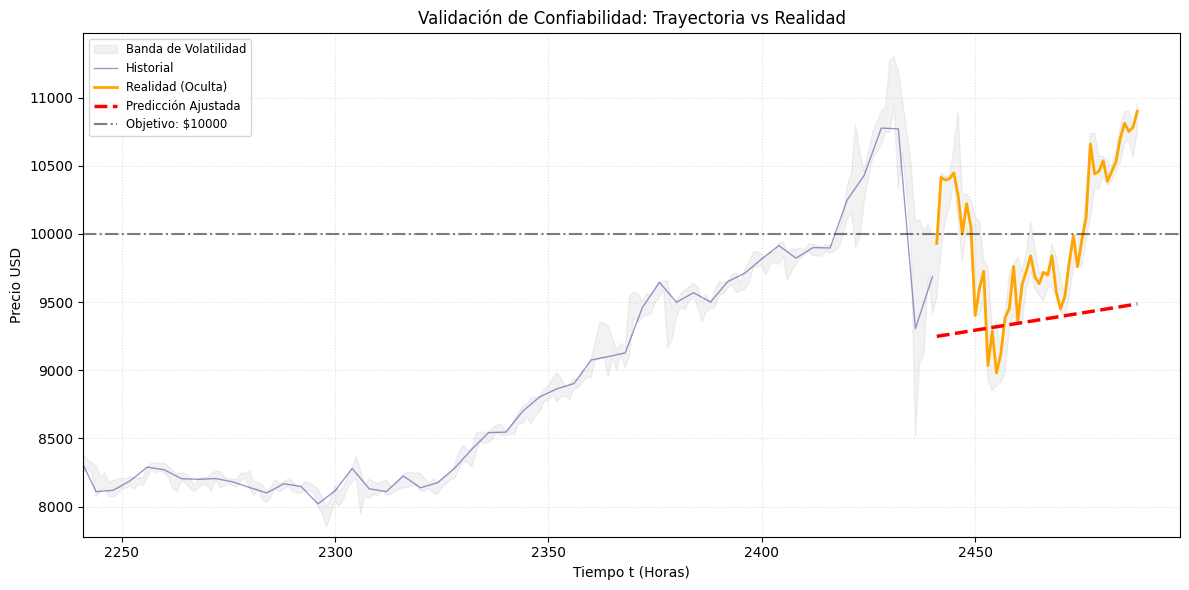

--- REPORTE FINAL DE CALIDAD ---
Error Absoluto (RMSE): $769.01 USD
ERROR RELATIVO: 7.71%
ANÁLISIS DE PRECISIÓN: Aceptable
--------------------------------------------------
Precio objetivo de prueba colocado: $10,000.00 USD
Diferencia actual respecto al objetivo: $513.47 USD
--------------------------------------------------
RECOMENDACIÓN FINAL: RECOMENDADO: El objetivo es coherente con la inercia del modelo.


In [ ]:
#@title Fase 6: Reporte Final de Métricas y Recomendación
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# --- 1. SEGMENTACIÓN DE DATOS (Hold-out 48h) ---
n_prueba = 48
entrenamiento = df_analisis.iloc[:-n_prueba]
prueba = df_analisis.iloc[-n_prueba:]

# --- 2. ENTRENAMIENTO DEL MODELO DE VALIDACIÓN ---
grado_val = 3
coef_val = np.polyfit(entrenamiento['t'], entrenamiento['close_price'], grado_val)
modelo_val = np.poly1d(coef_val)

t_test = prueba['t'].values
y_real = prueba['close_price'].values
y_pred = modelo_val(t_test)

# --- 3. CÁLCULO DE MÉTRICAS TÉCNICAS ---
# Error Absoluto (RMSE)
rmse_val = np.sqrt(mean_squared_error(y_real, y_pred))
# Error Relativo (%)
precio_medio = y_real.mean()
error_relativo = (rmse_val / precio_medio) * 100
# Diferencia numérica con el objetivo
distancia_usd = precio_objetivo - y_pred[-1]

# --- 4. GRÁFICA TÉCNICA (Visualización Espaciosa) ---
plt.figure(figsize=(12, 6))

# Sombra de Volatilidad (Fase 2)
plt.fill_between(df_analisis['t'], df_analisis['low_price'], df_analisis['high_price'],
                 color='gray', alpha=0.1, label='Banda de Volatilidad')

# Historial Suavizado (Muestreo cada 4 puntos para evitar saturación)
plt.plot(entrenamiento['t'][::4], entrenamiento['close_price'][::4],
         color='navy', alpha=0.4, linewidth=1, label='Historial')

# Realidad Oculta y Predicción
plt.plot(t_test, y_real, color='orange', linewidth=2, label='Realidad (Oculta)')
plt.plot(t_test, y_pred, color='red', linestyle='--', linewidth=2.5, label='Predicción Ajustada')

# Línea de Objetivo
plt.axhline(y=precio_objetivo, color='black', linestyle='-.', alpha=0.5, label=f'Objetivo: ${precio_objetivo}')

# Ajuste de Zoom (Enfoque en la transición final)
t_inicio_vista = max(df_analisis['t'].min(), t_test[0] - 200)
plt.xlim(t_inicio_vista, t_test[-1] + 10)

# Ajuste dinámico del eje Y para claridad visual
precios_en_vista = df_analisis[df_analisis['t'] >= t_inicio_vista]['close_price']
plt.ylim(min(precios_en_vista.min(), precio_objetivo) * 0.98,
         max(precios_en_vista.max(), precio_objetivo) * 1.02)

plt.title('Validación de Confiabilidad: Trayectoria vs Realidad', fontsize=12)
plt.xlabel('Tiempo t (Horas)')
plt.ylabel('Precio USD')
plt.legend(loc='upper left', fontsize='small', frameon=True)
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

# --- 5. REPORTE TÉCNICO DE RESULTADOS ---
print(f"--- REPORTE FINAL DE CALIDAD ---")
print(f"Error Absoluto (RMSE): ${rmse_val:.2f} USD")
print(f"ERROR RELATIVO: {error_relativo:.2f}%")
print(f"ANÁLISIS DE PRECISIÓN: {'Alta' if error_relativo < 5 else 'Aceptable' if error_relativo < 10 else 'Baja'}")
print("-" * 50)
print(f"Precio objetivo de prueba colocado: ${precio_objetivo:,.2f} USD")
print(f"Diferencia actual respecto al objetivo: ${distancia_usd:,.2f} USD")
print("-" * 50)

# Lógica de Recomendación Final
# Se recomienda si el error es aceptable y el objetivo sigue la inercia de la curva
es_convergente = (y_pred[-1] > y_pred[0] and precio_objetivo > y_pred[-1]) or \
                 (y_pred[-1] < y_pred[0] and precio_objetivo < y_pred[-1])

if error_relativo < 10 and es_convergente:
    recomendacion = "RECOMENDADO: El objetivo es coherente con la inercia del modelo."
else:
    recomendacion = "NO RECOMENDADO: El objetivo es divergente o la fiabilidad es insuficiente."

print(f"RECOMENDACIÓN FINAL: {recomendacion}")